---
---
## Trabajo Práctico 5 - Estimación de Intervalos
---
---

Considerar $n=32$ lanzamientos de una moneda cargada con probabilidad $p$ de salir cara. El numero de caras $X$ es una variable aleatoria con distribucion binomial $X \sim B(n, p)$. Considerar
un tanda de lanzamientos en el que salen $k$ caras. El estimador del
parametro $p$ es $\hat{p} = \frac{k}{n}$. El intervalo de confianza estándar de $p$ con un nivel de confianza del $95\%$ es $\hat{p} \pm 1.96\sqrt{\hat{p}(1 − \hat{p})/n}$, donde $q = 1.96$ es el cuantil normal estandar para un $95\%$ CL.

  * Simular 10.000 tandas de lanzamientos asumiendo $p = 0.2$.

  * Verificar para cada tanda si el intervalo incluye o no a $p = 0.2$.

  * Estimar la cobertura del intervalo.

  * Decidir si el intervalo es exacto y comparar la cobertura con respecto al nivel de confianza.

  * Barrer $p$ en el intervalo [0,1] en pasos de $0.01$, graficar y ver si hay valores de $p$ para los cuáles la cobertura es particularmente mala.

  * Estimar la cobertura de un nuevo intervalo $t \pm 1.96 \sqrt{t(1 − t)/n}$ con $t = (k + 2)/(n + 4)$, equivalente a “agregar dos  aciertos y dos fracasos”.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
# definimos los parametros
n = 32
p = 0.2
sim = 10000
q = 1.96

In [3]:
# simulamos los datos y calculamos estimadores y sus errores
k_val = np.random.binomial(n, p, size=sim)
p_hat = k_val/n
p_hat_err = np.sqrt(p_hat*(1-p_hat)/n)

In [4]:
# calculamos la probabilidad de cobertura
j = np.where(p_hat >= p - q*p_hat_err, True, False)
cobertura = np.sum(j)/sim
print(f'La cobertura del intervalo es: {cobertura*100:.2f}%')

La cobertura del intervalo es: 90.90%


Obtenemos una probabilidad de cobertura de 90%, lo cual no coincide con el niverl de concianza (95%), por lo que podemos decir que el intervalo no es exacto.

Entonces vamos a barrer $p$ en el intervalo $[0,1]$ y calcularemos la cobertura en función de $p$

In [5]:
# Creamos el vector con los valores de p
vector_p = np.arange(0, 1.01, 0.01)

# Datos simulados para todas las probabilidades de éxito (usamos vectorización)
val_sim = stats.binom.rvs(n, vector_p[:,np.newaxis], size=(len(vector_p), sim))

# Calculamos los intervalos de nivel de confianza de 95%
p_hat_v = val_sim / n
delta_p_hat_v = 1.96 * np.sqrt(p_hat_v * (1 - p_hat_v) / n)
lim_up = p_hat_v + delta_p_hat_v
lim_low = p_hat_v - delta_p_hat_v

# Calculamos la probabilidad de cobertura
cond= (vector_p[:, np.newaxis] > lim_low) & (vector_p[:, np.newaxis] < lim_up)
coberturas = np.mean(cond, axis=1)

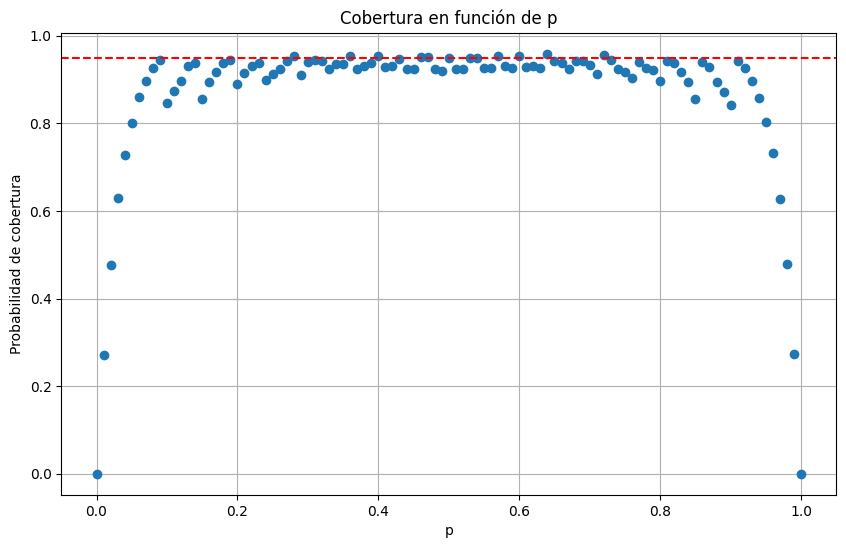

In [6]:
# graficamos cobertura en funcion de p
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_title('Cobertura en función de p')
ax1.set_xlabel('p')
ax1.set_ylabel('Probabilidad de cobertura')

ax1.plot(vector_p, coberturas, marker = 'o', linestyle = 'none')
# grafico una linea horizontal para mostrar  el niverl de confianza de 95%
ax1.axhline(0.95, color='r', linestyle='--')
ax1.grid()

Vemos entonces que cerca de los extremos, en $p ≈ 0$ y $p ≈ 1$, la cobertura se aleja mucho del nivel de confianza de 95%, es decir, la cobertura en estas regiones es mala.

Ahora queremos estimar la cobertura para un intervalo $t \pm 1.96 \sqrt{t(1 − t)/n}$ con $t = (k + 2)/(n + 4)$, equivalente a “agregar dos  aciertos y dos fracasos”.

In [7]:
# Calculamos los intervalos de nivel de confianza de 95%, pero usando el estimador t
t_hat = (val_sim + 2)/(n + 4)
t_hat_err = 1.96*np.sqrt(t_hat * (1 - t_hat) / n)
t_lim_up = t_hat + t_hat_err
t_lim_low = t_hat - t_hat_err

# Calculamos la probabilidad de cobertura
cond_t = (vector_p[:, np.newaxis] > t_lim_low) & (vector_p[:, np.newaxis] < t_lim_up)
coberturas_t = np.mean(cond_t, axis=1)

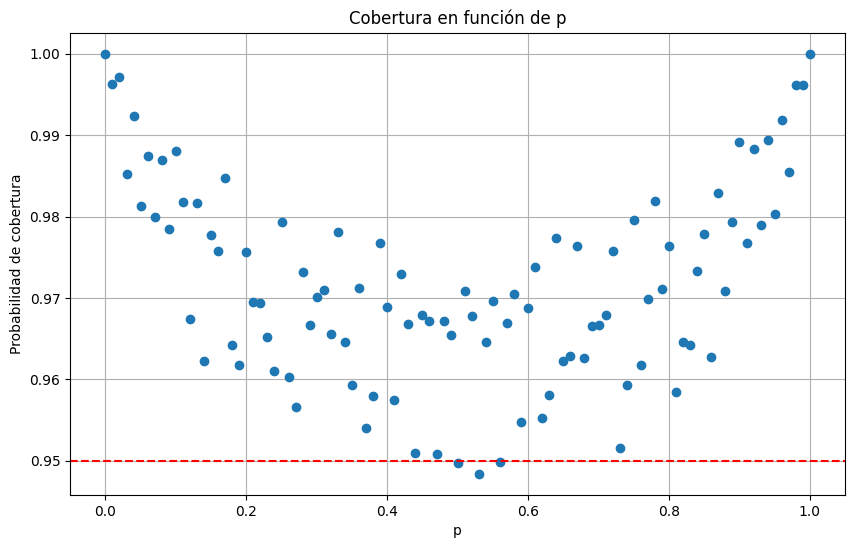

In [8]:
# graficamos cobertura en funcion de p
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_title('Cobertura en función de p')
ax2.set_xlabel('p')
ax2.set_ylabel('Probabilidad de cobertura')

ax2.plot(vector_p, coberturas_t, marker = 'o', linestyle = 'none')
# grafico una linea horizontal para mostrar  el niverl de confianza de 95%
ax2.axhline(0.95, color='r', linestyle='--')
ax2.grid()

Vemos que en este caso con este estimador la probabilidad de cobertura resulta mayor que el nivel de confianza de 95%. Al igual que antes, vemos que en los extremos es donde la probabilidad mas se aleja de 0.95.